# banknotes_NB.R - solution


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, confusion_matrix
)

plt.rcParams['figure.figsize'] = (8, 8)
seed = 31287

In [33]:
data = pd.read_csv('data/banknotes_data.csv')
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [34]:
data_train, data_test = train_test_split(
    data, test_size=0.2, shuffle=True,
    stratify=data['counterfeit'], random_state=seed
)

lbls_train = data_train['counterfeit']
lbls_test  = data_test['counterfeit']

feature_cols = [c for c in data.columns if c != 'counterfeit']

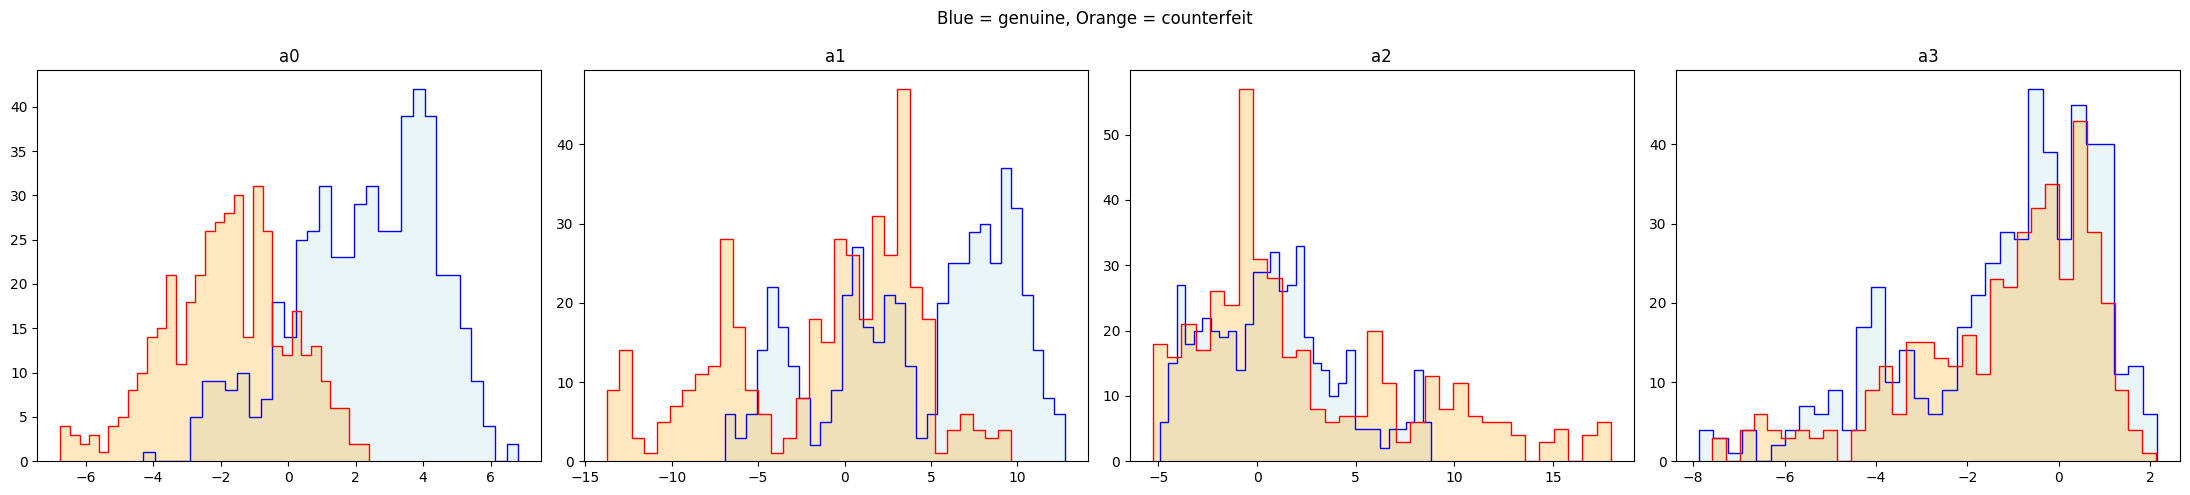

In [35]:
# Exploratory histograms
fig, ax = plt.subplots(1, len(feature_cols), figsize=(22, 5))
for i, col in enumerate(feature_cols):
    ax[i].hist(data_train[lbls_train==0][col], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1][col], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0][col], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1][col], bins=32, histtype='bar', color='orange', alpha=0.25)
    ax[i].set_title(col)
plt.suptitle('Blue = genuine, Orange = counterfeit')
plt.tight_layout()
plt.show()

## Helper functions

In [36]:
def eval_model(clf, X_train, X_test, y_train, y_test, label, show_train_cm=True):
    clf.fit(X_train, y_train)

    proba_train = clf.predict_proba(X_train)[:, 1]
    proba_test  = clf.predict_proba(X_test)[:, 1]

    fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_train)
    fpr_te, tpr_te, _ = roc_curve(y_test,  proba_test)

    auc_tr = roc_auc_score(y_train, proba_train)
    auc_te = roc_auc_score(y_test,  proba_test)

    pred_train = clf.predict(X_train)
    pred_test  = clf.predict(X_test)

    cm_train = confusion_matrix(y_train, pred_train, normalize='true')
    cm_test  = confusion_matrix(y_test,  pred_test,  normalize='true')

    print(f'Train AUC: {auc_tr}, Test AUC: {auc_te}')
    print(classification_report(y_test, pred_test, target_names=['genuine','counterfeit']))

    ncols = 2 if show_train_cm else 1
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if show_train_cm:
        ConfusionMatrixDisplay(cm_train, display_labels=['genuine','counterfeit']).plot(
            ax=axes[0], colorbar=False)
        axes[0].set_title(f'{label} – Train ')
        ax_test = axes[1]
    else:
        ax_test = axes
    ConfusionMatrixDisplay(cm_test, display_labels=['genuine','counterfeit']).plot(
        ax=ax_test, colorbar=False)
    ax_test.set_title(f'{label} – Test ')
    plt.tight_layout()
    plt.show()

    return fpr_tr, tpr_tr, auc_tr, fpr_te, tpr_te, auc_te

## Problem 1 – Gaussian Naive Bayes with one feature

**Feature selection:** We pick the single feature that gives the highest test AUC  
when used alone in a GaussianNB classifier.  
Looking at the histograms, the feature with the least class overlap is the best candidate.
We verify this automatically below.

In [37]:
print('Univariate AUC per feature :')
best_auc, best_feat = 0, feature_cols[0]
for col in feature_cols:
    clf_tmp = GaussianNB()
    clf_tmp.fit(data_train[[col]], lbls_train)
    auc = roc_auc_score(lbls_test,
                        clf_tmp.predict_proba(data_test[[col]])[:, 1])
    print(f'{col}:  AUC={auc}')
    if auc > best_auc:
        best_auc, best_feat = auc, col

print(f"Chosen feature: '{best_feat}'  (AUC={best_auc})")

Univariate AUC per feature :
a0:  AUC=0.9442677514792899
a1:  AUC=0.7328032544378698
a2:  AUC=0.5443047337278106
a3:  AUC=0.515051775147929
Chosen feature: 'a0'  (AUC=0.9442677514792899)


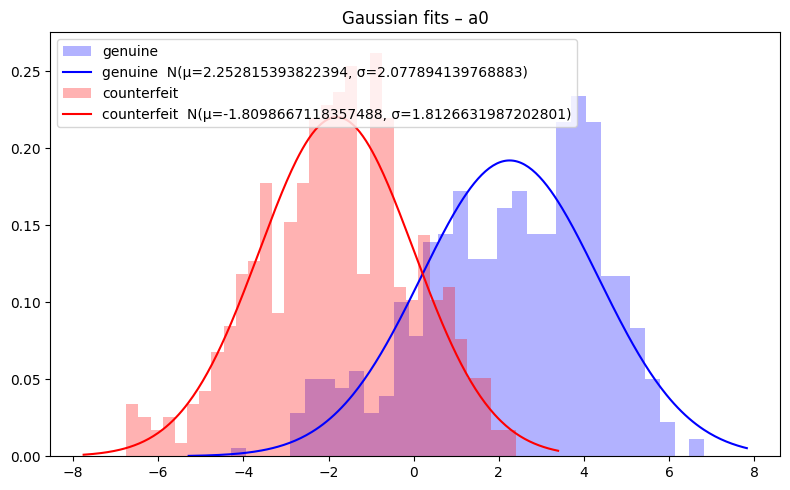

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
for cls, color, name in [(0,'blue','genuine'), (1,'red','counterfeit')]:
    vals = data_train[lbls_train == cls][best_feat]
    mu, sigma = st.norm.fit(vals)
    x = np.linspace(vals.min()-1, vals.max()+1, 300)
    ax.hist(vals, bins=32, density=True, alpha=0.3, color=color, label=name)
    ax.plot(x, st.norm.pdf(x, mu, sigma), color=color,
            label=f'{name}  N(μ={mu}, σ={sigma})')
ax.set_title(f'Gaussian fits – {best_feat}')
ax.legend()
plt.tight_layout()
plt.show()

Train AUC: 0.921726073899987, Test AUC: 0.9442677514792899
              precision    recall  f1-score   support

     genuine       0.86      0.88      0.87       130
 counterfeit       0.84      0.82      0.83       104

    accuracy                           0.85       234
   macro avg       0.85      0.85      0.85       234
weighted avg       0.85      0.85      0.85       234



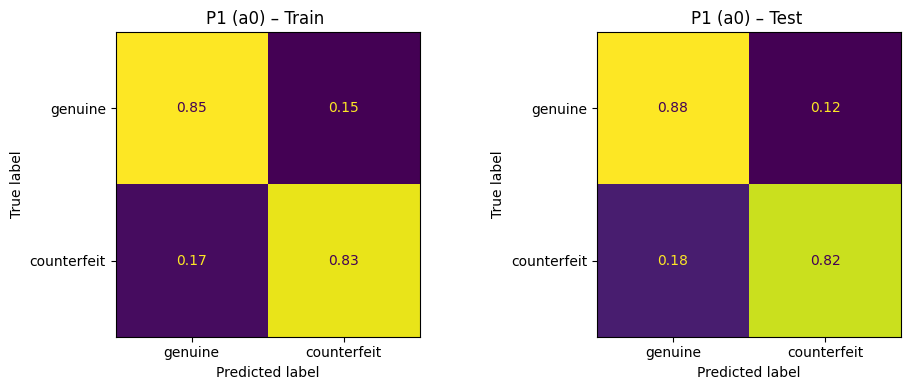

In [39]:
clf1 = GaussianNB()
X_tr1 = data_train[[best_feat]]
X_te1 = data_test[[best_feat]]

fpr_tr1, tpr_tr1, auc_tr1, fprs_test_a0, tprs_test_a0, auc_te1 = eval_model(
    clf1, X_tr1, X_te1, lbls_train, lbls_test,
    label=f'P1 ({best_feat})')

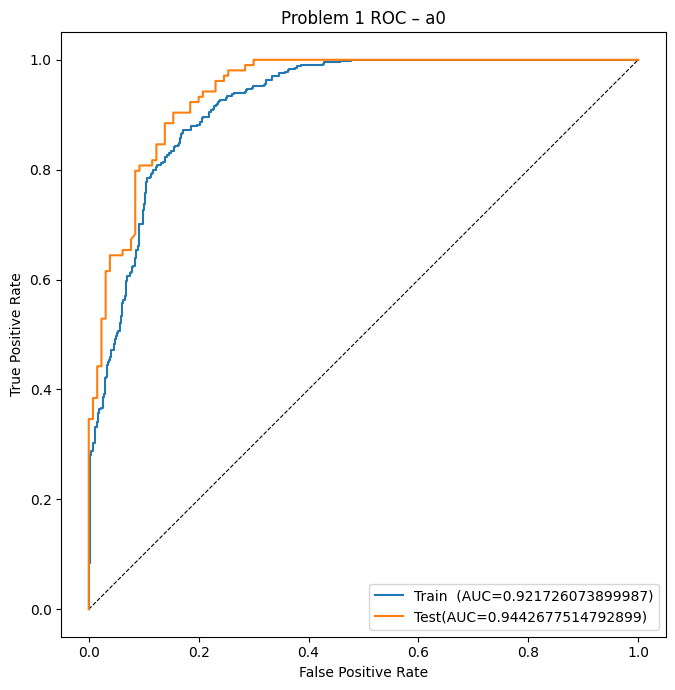

In [40]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect(1.0)
ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.plot(fpr_tr1, tpr_tr1, label=f'Train  (AUC={auc_tr1})')
ax.plot(fprs_test_a0, tprs_test_a0, label=f'Test(AUC={auc_te1})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Problem 1 ROC – {best_feat}')
ax.legend()
plt.tight_layout()
plt.show()

## Problem 2 – Gaussian Naive Bayes with two features

We keep `best_feat` and search for the second feature that, combined with it, gives the highest test AUC.

In [41]:
remaining = [c for c in feature_cols if c != best_feat]
print('Two-feature AUC:')
best_auc2, best_feat2 = 0, remaining[0]
for col in remaining:
    cols = [best_feat, col]
    clf_tmp = GaussianNB()
    clf_tmp.fit(data_train[cols], lbls_train)
    auc = roc_auc_score(lbls_test,
                        clf_tmp.predict_proba(data_test[cols])[:, 1])
    print(f'{best_feat} + {col}  AUC={auc}')
    if auc > best_auc2:
        best_auc2, best_feat2 = auc, col

print(f"Best pair: '{best_feat}' + '{best_feat2}'  (AUC={best_auc2})")

Two-feature AUC:
a0 + a1  AUC=0.9637573964497042
a0 + a2  AUC=0.9381656804733728
a0 + a3  AUC=0.9446745562130178
Best pair: 'a0' + 'a1'  (AUC=0.9637573964497042)


Train AUC: 0.9499748195400369, Test AUC: 0.9637573964497042
              precision    recall  f1-score   support

     genuine       0.87      0.91      0.89       130
 counterfeit       0.88      0.84      0.86       104

    accuracy                           0.88       234
   macro avg       0.88      0.87      0.87       234
weighted avg       0.88      0.88      0.88       234



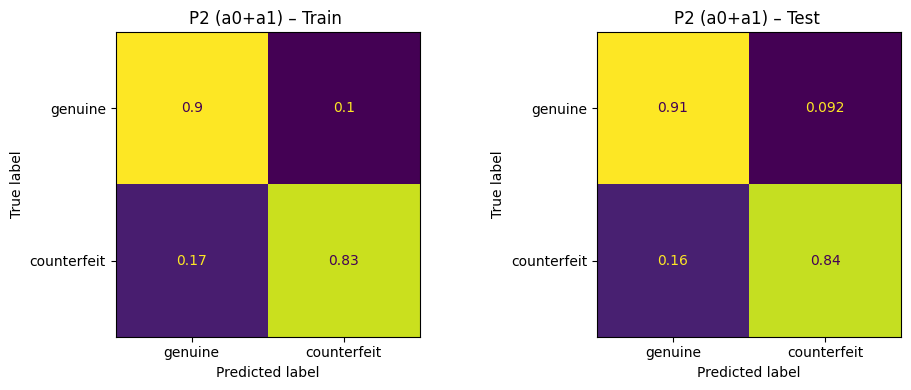

In [42]:
clf2 = GaussianNB()
X_tr2 = data_train[[best_feat, best_feat2]]
X_te2 = data_test[[best_feat, best_feat2]]

fpr_tr2, tpr_tr2, auc_tr2, fprs_test_a0a1, tprs_test_a0a1, auc_te2 = eval_model(
    clf2, X_tr2, X_te2, lbls_train, lbls_test,
    label=f'P2 ({best_feat}+{best_feat2})')

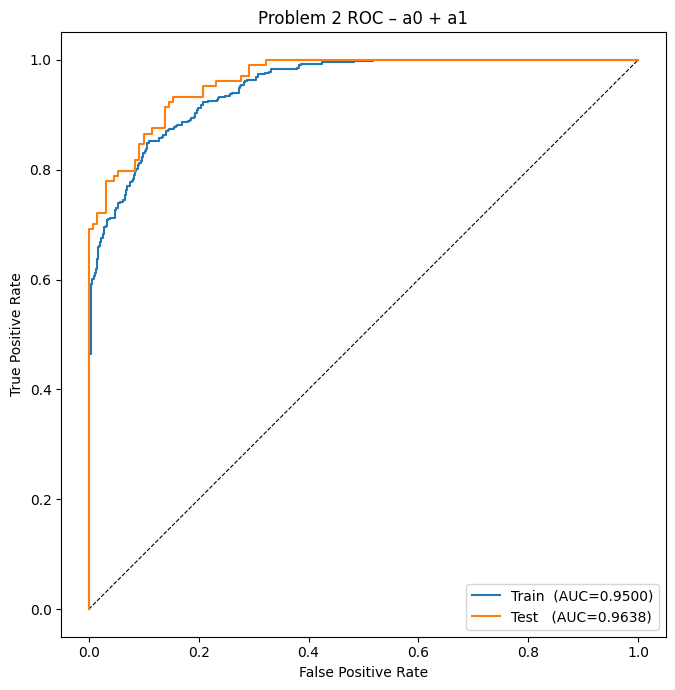

AUC improvement (test): +0.0195


In [43]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect(1.0)
ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.plot(fpr_tr2, tpr_tr2, label=f'Train  (AUC={auc_tr2:.4f})')
ax.plot(fprs_test_a0a1, tprs_test_a0a1, label=f'Test   (AUC={auc_te2:.4f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Problem 2 ROC – {best_feat} + {best_feat2}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'AUC improvement (test): {auc_te2 - auc_te1:+.4f}')

## Problem 3 – Gaussian Naive Bayes with all features

Confusion matrix shown only for the test set, then all three ROC curves are compared.

Train AUC: 0.9347732825993696, Test AUC: 0.9520710059171598
              precision    recall  f1-score   support

     genuine       0.85      0.89      0.87       130
 counterfeit       0.86      0.80      0.83       104

    accuracy                           0.85       234
   macro avg       0.85      0.85      0.85       234
weighted avg       0.85      0.85      0.85       234



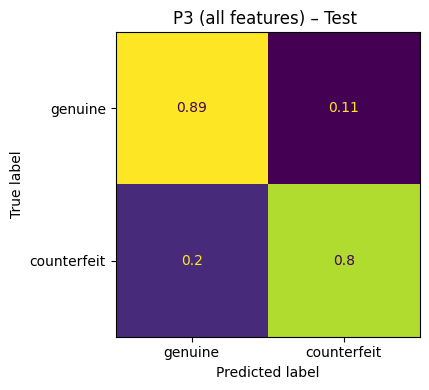

In [44]:
clf3 = GaussianNB()
X_tr3 = data_train[feature_cols]
X_te3 = data_test[feature_cols]

fpr_tr3, tpr_tr3, auc_tr3, fprs_test_all, tprs_test_all, auc_te3 = eval_model(
    clf3, X_tr3, X_te3, lbls_train, lbls_test,
    label='P3 (all features)',
    show_train_cm=False)

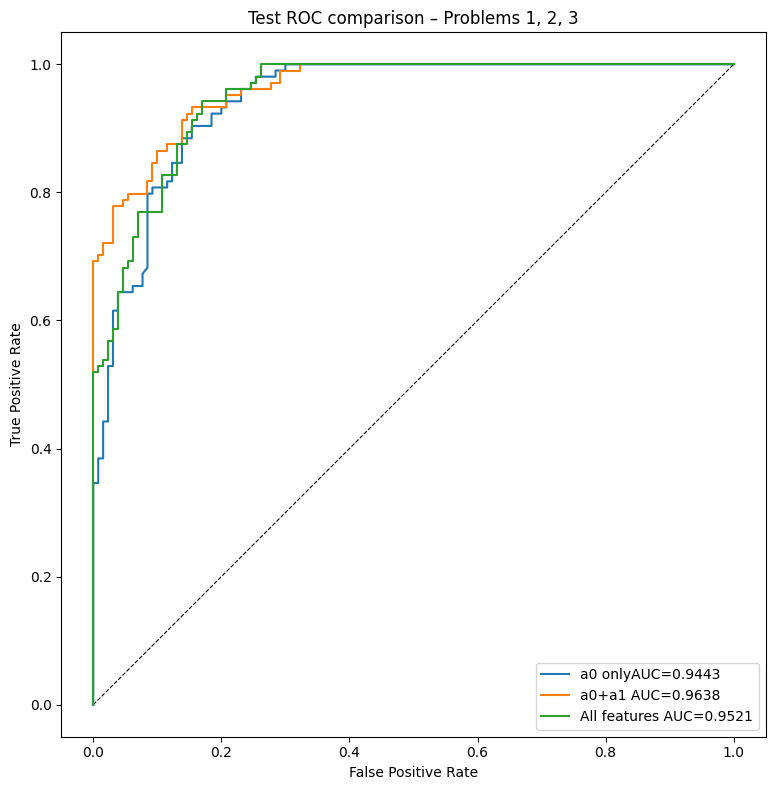

P1 (1 feature): 0.9442677514792899
P2 (2 features): 0.9637573964497042,delta=+0.0195
P3 (all feats): 0.9520710059171598, delta=-0.0117


In [45]:
# final
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.plot(fprs_test_a0,   tprs_test_a0,
        label=f'{best_feat} onlyAUC={auc_te1:.4f}')
ax.plot(fprs_test_a0a1, tprs_test_a0a1,
        label=f'{best_feat}+{best_feat2} AUC={auc_te2:.4f}')
ax.plot(fprs_test_all,  tprs_test_all,
        label=f'All features AUC={auc_te3:.4f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Test ROC comparison – Problems 1, 2, 3')
ax.legend()
plt.tight_layout()
plt.show()

print(f'P1 (1 feature): {auc_te1}')
print(f'P2 (2 features): {auc_te2},delta={auc_te2-auc_te1:+.4f}')
print(f'P3 (all feats): {auc_te3}, delta={auc_te3-auc_te2:+.4f}')